# Modelo 10 clases


In [1]:
import tensorflow as tf
import os

In [2]:
Ruta = r"C:/Users/gerar/Desktop/Analizador-de-Textura-main/Modelo2026/10clases"
Imagenes = (128, 128)
Batch = 32

In [3]:
train_ds = tf.keras.utils.image_dataset_from_directory(
    Ruta,
    validation_split=0.2,   # Reservamos el 20% para pruebas
    subset="training",
    seed=123,               # Semilla para que el orden sea reproducible
    image_size=Imagenes,
    batch_size=Batch
)

Found 1168 files belonging to 10 classes.
Using 935 files for training.


In [4]:
val_ds = tf.keras.utils.image_dataset_from_directory(
    Ruta,
    validation_split=0.2,
    subset="validation",
    seed=123,
    image_size=Imagenes,
    batch_size=Batch
)

Found 1168 files belonging to 10 classes.
Using 233 files for validation.


In [5]:
print(f"Clases encontradas: {train_ds.class_names}")

Clases encontradas: ['banded', 'blotchy', 'braided', 'bubbly', 'bumpy', 'chequered', 'cobwebbed', 'cracked', 'crosshatched', 'crystalline']


In [ ]:
from tensorflow.keras import layers, models
import tensorflow as tf

# 1. Capa de aumento de datos 
# Esto genera variaciones leves para que no se aprenda las fotos de memoria
data_augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.1), # Rotación muy leve para no perder la textura
])

model = models.Sequential([
    layers.Input(shape=(128, 128, 3)),
    data_augmentation,
    
    # Capa de Normalización original
    layers.Rescaling(1./255),

    # BLOQUE 1: Bordes
    layers.Conv2D(32, (3, 3), activation='relu', padding='same'),
    layers.BatchNormalization(), # Agregamos esto para estabilizar el aprendizaje
    layers.MaxPooling2D((2, 2)),

    # BLOQUE 2: Patrones
    layers.Conv2D(64, (3, 3), activation='relu', padding='same'),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2, 2)),

    # BLOQUE 3: Estructuras complejas
    layers.Conv2D(128, (3, 3), activation='relu', padding='same'),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2, 2)),

    # CLASIFICACIÓN
    layers.Flatten(),
    layers.Dense(256, activation='relu'), # Aumentamos un poco la capacidad aquí
    layers.Dropout(0.5),                  
    layers.Dense(10, activation='softmax')
])


opt = tf.keras.optimizers.Adam(learning_rate=0.0005) 

model.compile(
    optimizer=opt,
    loss=tf.keras.losses.SparseCategoricalCrossentropy(),
    metrics=['accuracy']
)

model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ sequential (Sequential)         │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rescaling (Rescaling)           │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 128, 128, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 128, 128, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 64, 64, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 64, 64, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 32, 32, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 32, 32, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 32768)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │     8,388,864 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 8,485,578 (32.37 MB)

 Trainable params: 8,485,130 (32.37 MB)

 Non-trainable params: 448 (1.75 KB)

In [23]:


history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=30, 
)

Epoch 1/30
30/30 ━━━━━━━━━━━━━━━━━━━━ 11s 358ms/step - accuracy: 0.9187 - loss: 0.2313 - val_accuracy: 0.5064 - val_loss: 3.8168
Epoch 2/30
30/30 ━━━━━━━━━━━━━━━━━━━━ 11s 359ms/step - accuracy: 0.9048 - loss: 0.2861 - val_accuracy: 0.5451 - val_loss: 3.6621
Epoch 3/30
30/30 ━━━━━━━━━━━━━━━━━━━━ 11s 351ms/step - accuracy: 0.9155 - loss: 0.2404 - val_accuracy: 0.5107 - val_loss: 3.5716
Epoch 4/30
30/30 ━━━━━━━━━━━━━━━━━━━━ 10s 318ms/step - accuracy: 0.9123 - loss: 0.2709 - val_accuracy: 0.4979 - val_loss: 3.7566
Epoch 5/30
30/30 ━━━━━━━━━━━━━━━━━━━━ 10s 317ms/step - accuracy: 0.9037 - loss: 0.2768 - val_accuracy: 0.5064 - val_loss: 3.8514
Epoch 6/30
30/30 ━━━━━━━━━━━━━━━━━━━━ 9s 315ms/step - accuracy: 0.9144 - loss: 0.2424 - val_accuracy: 0.4936 - val_loss: 4.2405
Epoch 7/30
30/30 ━━━━━━━━━━━━━━━━━━━━ 9s 314ms/step - accuracy: 0.9112 - loss: 0.2510 - val_accuracy: 0.5064 - val_loss: 3.7495
Epoch 8/30
30/30 ━━━━━━━━━━━━━━━━━━━━ 10s 318ms/step - accuracy: 0.9155 - loss: 0.2332 - val_accura

In [ ]:
import numpy as np
import tensorflow as tf
from tensorflow.keras.preprocessing import image
import matplotlib.pyplot as plt
import os


Ruta_Pruebas = r"C:/Users/gerar/Desktop/Analizador-de-Textura-main/Modelo2026/10clasesPrueba"
Imagenes_Size = (128, 128)

nombres_clases = train_ds.class_names 

def predecir_y_mostrar(ruta_imagen):
    # Cargar imagen para el modelo 
    img_modelo = image.load_img(ruta_imagen, target_size=Imagenes_Size)
    img_array = image.img_to_array(img_modelo)
    img_array = tf.expand_dims(img_array, 0) 

    # Predicción
    predicciones = model.predict(img_array, verbose=0)
    # Aplicamos softmax para obtener probabilidades 
    score = tf.nn.softmax(predicciones[0])
    
    clase_predicha = nombres_clases[np.argmax(score)]
    confianza = 100 * np.max(score)

    # Visualización 
    img_display = image.load_img(ruta_imagen) 
    plt.figure(figsize=(4, 4))
    plt.imshow(img_display)
    plt.title(f"Predicción: {clase_predicha}\nConfianza: {confianza:.2f}%")
    plt.axis('off')
    plt.show()

    return clase_predicha, confianza


print(f"Probando imágenes en: {Ruta_Pruebas}\n")


archivos = [f for f in os.listdir(Ruta_Pruebas) if f.lower().endswith(('.png', '.jpg', '.jpeg'))]

if not archivos:
    print("No se encontraron imágenes en la carpeta especificada.")
else:
    for archivo in archivos:
        ruta_completa = os.path.join(Ruta_Pruebas, archivo)
        clase, conf = predecir_y_mostrar(ruta_completa)
        print(f"Archivo: {archivo} -> Resultado: {clase} ({conf:.2f}%)")


Calculando predicciones para la matriz de confusión...


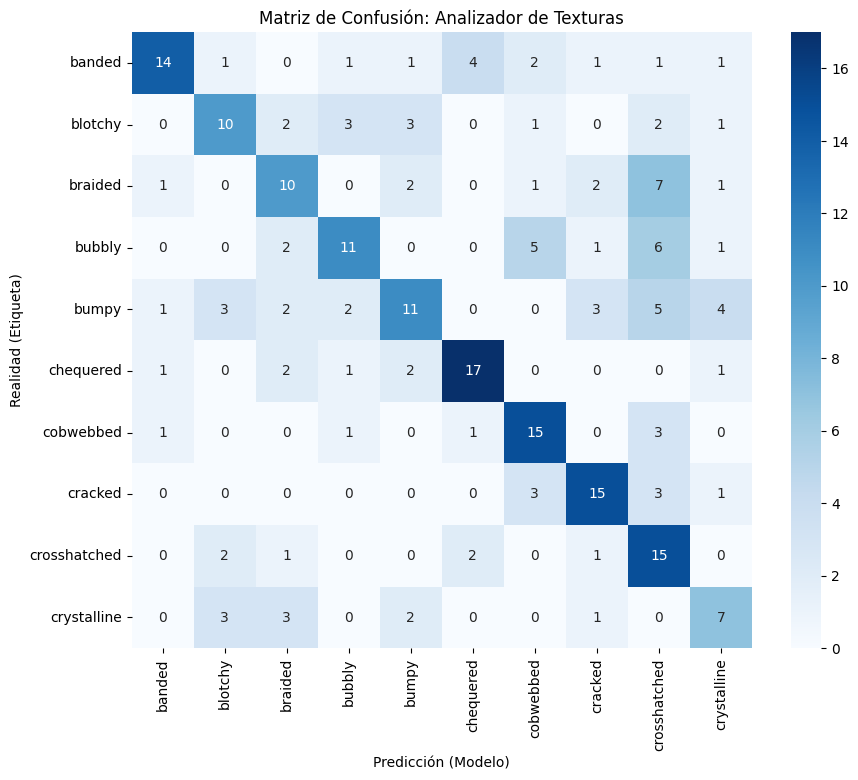


Reporte de Clasificación:
              precision    recall  f1-score   support

      banded       0.78      0.54      0.64        26
     blotchy       0.53      0.45      0.49        22
     braided       0.45      0.42      0.43        24
      bubbly       0.58      0.42      0.49        26
       bumpy       0.52      0.35      0.42        31
   chequered       0.71      0.71      0.71        24
   cobwebbed       0.56      0.71      0.62        21
     cracked       0.62      0.68      0.65        22
crosshatched       0.36      0.71      0.48        21
 crystalline       0.41      0.44      0.42        16

    accuracy                           0.54       233
   macro avg       0.55      0.54      0.54       233
weighted avg       0.56      0.54      0.54       233



In [24]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, classification_report

# 1. Obtener etiquetas reales y predicciones
y_true = []
y_pred = []

print("Calculando predicciones para la matriz de confusión...")

# Recorremos el dataset de validación
for imagenes, etiquetas in val_ds:
    preds = model.predict(imagenes, verbose=0)
    y_true.extend(etiquetas.numpy())
    y_pred.extend(np.argmax(preds, axis=1))

# 2. Crear la matriz de confusión
cm = confusion_matrix(y_true, y_pred)
nombres_clases = train_ds.class_names

# 3. Graficar
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=nombres_clases, 
            yticklabels=nombres_clases)
plt.xlabel('Predicción (Modelo)')
plt.ylabel('Realidad (Etiqueta)')
plt.title('Matriz de Confusión: Analizador de Texturas')
plt.show()

# 4. Mostrar reporte de métricas detallado
print("\nReporte de Clasificación:")
print(classification_report(y_true, y_pred, target_names=nombres_clases))